In [13]:
# import libraries
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

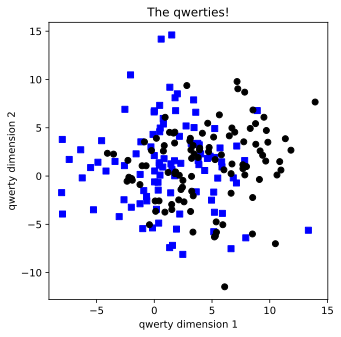

In [14]:
# parameters
nPerClust = 100
blur = 4

A = [  1, 1 ]
B = [  5, 1 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [31]:
def createANNmodel(learningRate):

  ANNclassify = nn.Sequential(
      nn.Linear(2,16),   # input layer
      nn.ReLU(),  
      nn.Linear(16,32),
      nn.ReLU(),           # activation unit
      nn.Linear(32,1),  # output unit
      nn.Sigmoid(),    # final activation unit (not needed b/c we use BCEWithLogitsLoss)
        )
  lossfun = nn.BCELoss()

  optimizer = torch.optim.SGD(ANNclassify.parameters(),lr=learningRate)

  return ANNclassify,lossfun,optimizer

In [32]:
numepochs = 1000

def trainTheModel(ANNmodel):

  losses = torch.zeros(numepochs)
  for epochi in range(numepochs):

    yHat = ANNmodel(data)
    loss = lossfun(yHat,labels)
    losses[epochi] = loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



  predictions = ANNmodel(data)
  totalacc = 100*torch.mean(((predictions>.5) == labels).float())

  return losses,predictions,totalacc

Final accuracy: 65%


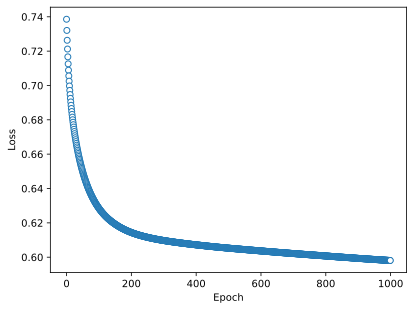

In [33]:
ANNclassify,lossfun,optimizer = createANNmodel(.01)

losses,predictions,totalacc = trainTheModel(ANNclassify)

print('Final accuracy: %g%%' %totalacc)

plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.xlabel('Epoch'), plt.ylabel('Loss')
plt.show()

Final accuracy: 65%


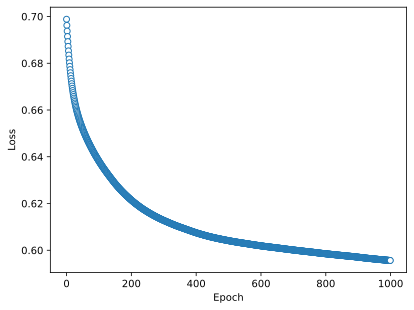

In [34]:
ANNclassify,lossfun,optimizer = createANNmodel(.01)

losses,predictions,totalacc = trainTheModel(ANNclassify)

print('Final accuracy: %g%%' %totalacc)

plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.xlabel('Epoch'), plt.ylabel('Loss')
plt.show()

In [35]:
learningrates = np.linspace(.001,.1,50)

accByLR = []
allLosses = np.zeros((len(learningrates),numepochs))

for i,lr in enumerate(learningrates):

  ANNclassify,lossfun,optimizer = createANNmodel(lr)
  losses,predictions,totalacc = trainTheModel(ANNclassify)

  accByLR.append(totalacc)
  allLosses[i,:] = losses.detach()


/tmp/ipykernel_416296/1552768160.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  allLosses[i,:] = losses.detach()


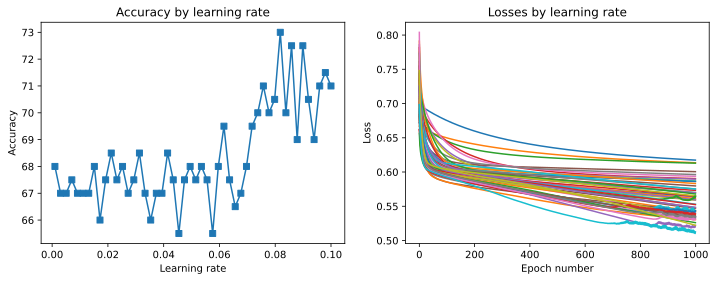

In [36]:
# plot the results
fig,ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(learningrates,accByLR,'s-')
ax[0].set_xlabel('Learning rate')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Accuracy by learning rate')

ax[1].plot(allLosses.T)
ax[1].set_title('Losses by learning rate')
ax[1].set_xlabel('Epoch number')
ax[1].set_ylabel('Loss')
plt.show()

In [37]:
# proportion of runs where the model had at least 70% accuracy
sum(torch.tensor(accByLR)>70)/len(accByLR)

tensor(0.1800)

In [22]:
# numExps = 50

# # matrix to store all results
# accMeta = np.zeros((numExps,len(learningrates)))

# # fewer epochs to reduce computation time
# numepochs = 500

# # now for the experiment
# for expi in range(numExps):
#   for i,lr in enumerate(learningrates):

#     # create and run the model
#     ANNclassify,lossfun,optimizer = createANNmodel(lr)
#     losses,predictions,totalacc = trainTheModel(ANNclassify)

#     # store the results
#     accMeta[expi,i] = totalacc



# # now plot the results, averaged over experiments
# plt.plot(learningrates,np.mean(accMeta,axis=0),'s-')
# plt.xlabel('Learning rate')
# plt.ylabel('Accuracy')
# plt.title('Accuracy by learning rate')
# plt.show()

In [23]:
# 1) The code creates a model with 16 hidden units. Notice where the two "16"s appear when constructing the model.
#    Recreate the model using 32 hidden units. Does that help with the issue of models getting stuck in local minima?
#
# 2) Adjust the code to create two hidden layers. The first hidden layer should have 16 hidden units and the second
#    hidden layer shuold have 32 units. What needs to change in the code to make the numbers match to prevent coding errors?
#